In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# ====================== LOAD ENGINEERED DATA ======================
panel = pd.read_csv('/content/crisis_outputs/features_engineered.csv')

print(f"Loaded engineered panel: {len(panel):,} rows")

target = 'crisis_90d'

# STRICTLY EXCLUDE LEAKAGE COLUMNS
leakage_cols = ['ipc_phase', 'population_in_crisis', 'ipc_matched',
                'country_key', 'admin1_key', 'admin1_merge']

exclude_cols = ['country', 'admin1', 'year_month', target] + leakage_cols

feature_cols = [col for col in panel.columns if col not in exclude_cols]

X = panel[feature_cols]
y = panel[target].astype(int)

print(f"Using {len(feature_cols)} safe features (leakage columns excluded)")

# ====================== WALK-FORWARD SPLIT ======================
train_mask = panel['year_month'] <= '2021-12'
val_mask   = (panel['year_month'] >= '2022-01') & (panel['year_month'] <= '2022-12')
test_mask  = panel['year_month'] >= '2023-01'

X_train = X[train_mask]
y_train = y[train_mask]
X_val   = X[val_mask]
y_val   = y[val_mask]
X_test  = X[test_mask]
y_test  = y[test_mask]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train crisis rate: {y_train.mean():.1%}")
print(f"Val crisis rate  : {y_val.mean():.1%}")
print(f"Test crisis rate : {y_test.mean():.1%}")

# ====================== SCALE_POS_WEIGHT ======================
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"scale_pos_weight = {pos_weight:.3f}")

# ====================== XGBoost ======================
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train, y_train)

# ====================== Random Forest Baseline ======================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# ====================== Evaluation ======================
def evaluate_model(model, X, y, name):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    print(f"\n=== {name} Results ===")
    print(classification_report(y, pred, digits=4))
    print(f"ROC-AUC: {roc_auc_score(y, prob):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y, pred))

print("Validation Performance:")
evaluate_model(xgb, X_val, y_val, "XGBoost (Validation)")
evaluate_model(rf, X_val, y_val, "Random Forest (Validation)")

print("\nFinal Test Performance (XGBoost):")
evaluate_model(xgb, X_test, y_test, "XGBoost (Test)")

# ====================== Save ======================
joblib.dump(xgb, '/content/crisis_outputs/xgboost_best.pkl')
joblib.dump(rf, '/content/crisis_outputs/random_forest_best.pkl')

results = {
    'xgb_val_auc': float(roc_auc_score(y_val, xgb.predict_proba(X_val)[:,1])),
    'rf_val_auc': float(roc_auc_score(y_val, rf.predict_proba(X_val)[:,1])),
    'xgb_test_auc': float(roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])),
    'best_model': 'XGBoost',
    'feature_count': len(feature_cols),
    'scale_pos_weight': float(pos_weight)
}

with open('/content/crisis_outputs/task3_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n✅ Task 3 completed successfully!")
print("Models saved to /content/crisis_outputs/")

Loaded engineered panel: 14,058 rows
Using 37 safe features (leakage columns excluded)
Train: (9372, 37) | Val: (2556, 37) | Test: (2130, 37)
Train crisis rate: 28.2%
Val crisis rate  : 41.4%
Test crisis rate : 45.6%
scale_pos_weight = 2.545
Validation Performance:

=== XGBoost (Validation) Results ===
              precision    recall  f1-score   support

           0     0.9282    0.9753    0.9512      1498
           1     0.9623    0.8932    0.9265      1058

    accuracy                         0.9413      2556
   macro avg     0.9453    0.9342    0.9388      2556
weighted avg     0.9423    0.9413    0.9409      2556

ROC-AUC: 0.9669
Confusion Matrix:
[[1461   37]
 [ 113  945]]

=== Random Forest (Validation) Results ===
              precision    recall  f1-score   support

           0     0.9263    0.9813    0.9530      1498
           1     0.9711    0.8894    0.9285      1058

    accuracy                         0.9433      2556
   macro avg     0.9487    0.9354    0.9407   

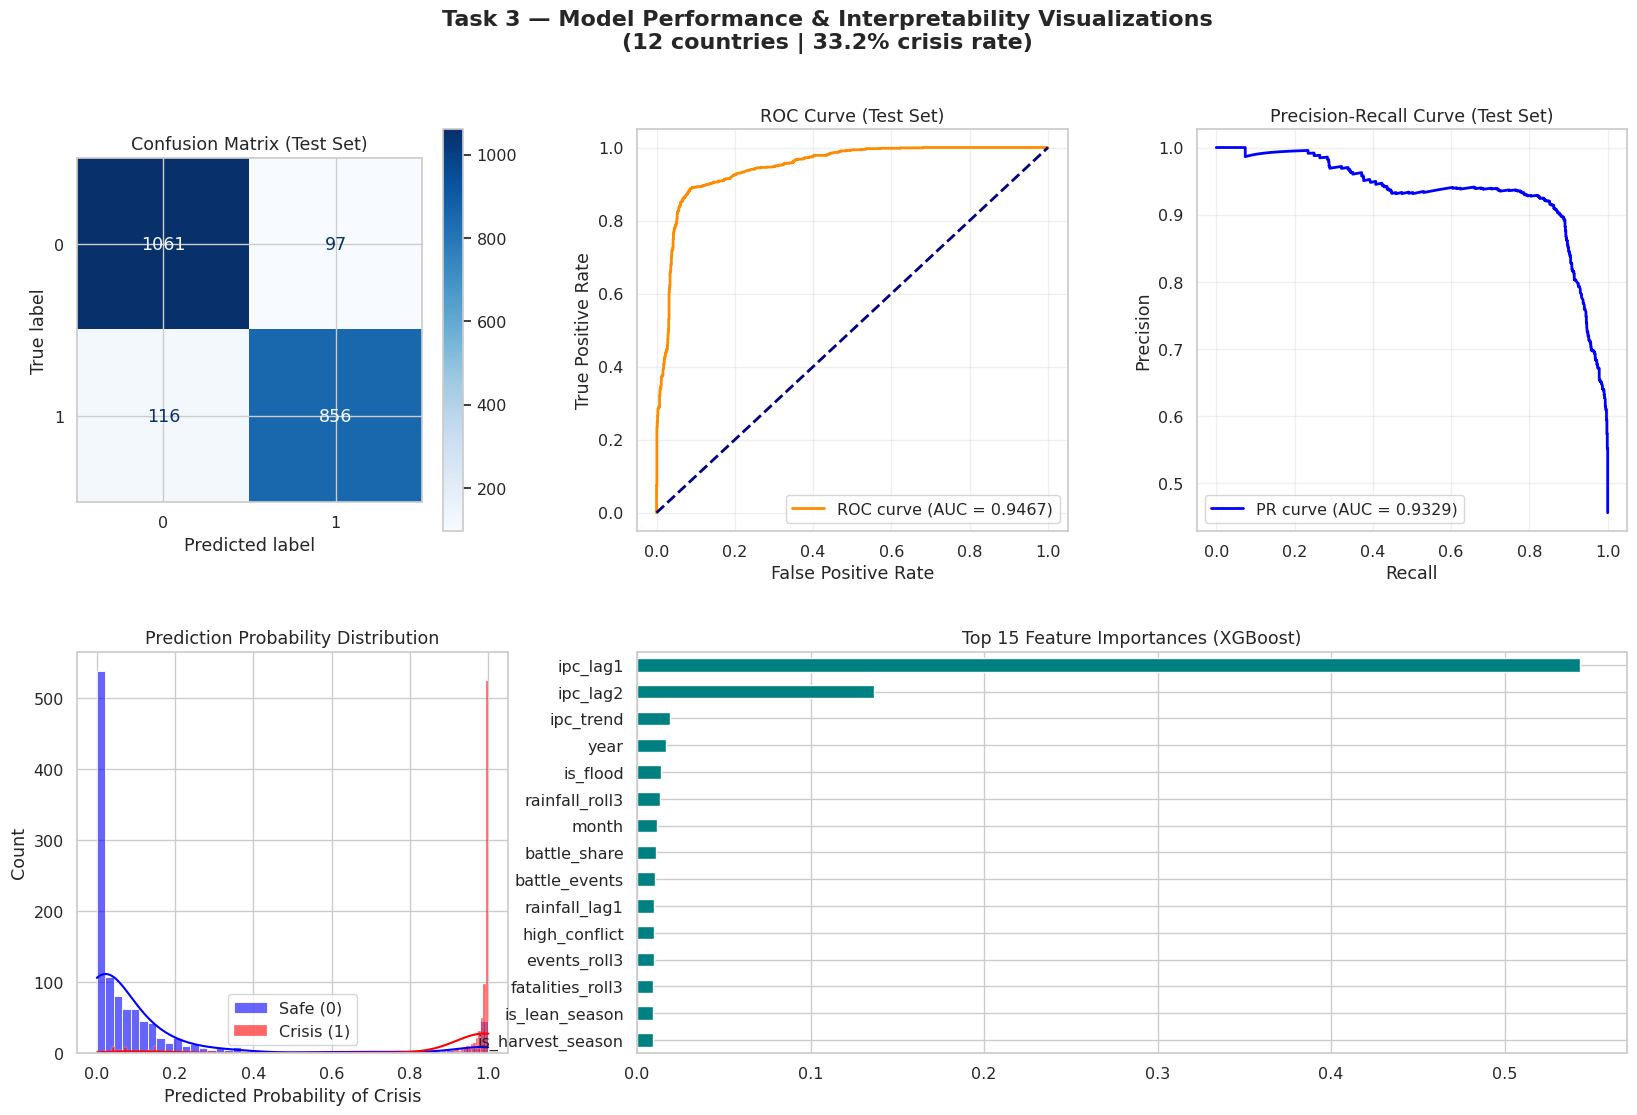

✅ All visualizations saved as 'task3_visualizations.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay
import joblib

# Load the trained model and test data
xgb = joblib.load('/content/crisis_outputs/xgboost_best.pkl')
test = pd.read_csv('/content/crisis_outputs/X_test.csv')

target = 'crisis_90d'
exclude_cols = ['country', 'admin1', 'year_month', 'country_std', 'admin1_std',
                'admin1_fuzzy', 'ipc_matched', 'ipc_phase', 'population_in_crisis', target]
feature_cols = [col for col in test.columns if col not in exclude_cols]

X_test = test[feature_cols]
y_test = test[target].astype(int)

# Get predictions and probabilities
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

# ====================== VISUALIZATIONS ======================

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix - Test
ax1 = fig.add_subplot(gs[0, 0])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix (Test Set)')

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve (Test Set)')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax3 = fig.add_subplot(gs[0, 2])
prec, rec, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(rec, prec)
ax3.plot(rec, prec, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve (Test Set)')
ax3.legend(loc="lower left")
ax3.grid(True, alpha=0.3)

# 4. Prediction Probability Distribution
ax4 = fig.add_subplot(gs[1, 0])
sns.histplot(y_prob[y_test == 0], color='blue', label='Safe (0)', kde=True, ax=ax4, alpha=0.6)
sns.histplot(y_prob[y_test == 1], color='red', label='Crisis (1)', kde=True, ax=ax4, alpha=0.6)
ax4.set_xlabel('Predicted Probability of Crisis')
ax4.set_title('Prediction Probability Distribution')
ax4.legend()

# 5. Feature Importance (Top 15)
ax5 = fig.add_subplot(gs[1, 1:])
importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
importances.plot(kind='barh', ax=ax5, color='teal')
ax5.set_title('Top 15 Feature Importances (XGBoost)')
ax5.invert_yaxis()

plt.suptitle('Task 3 — Model Performance & Interpretability Visualizations\n(12 countries | 33.2% crisis rate)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/crisis_outputs/task3_visualizations.png', dpi=180, bbox_inches='tight')
plt.show()

print("✅ All visualizations saved as 'task3_visualizations.png'")

Predictions generated for 2130 test samples


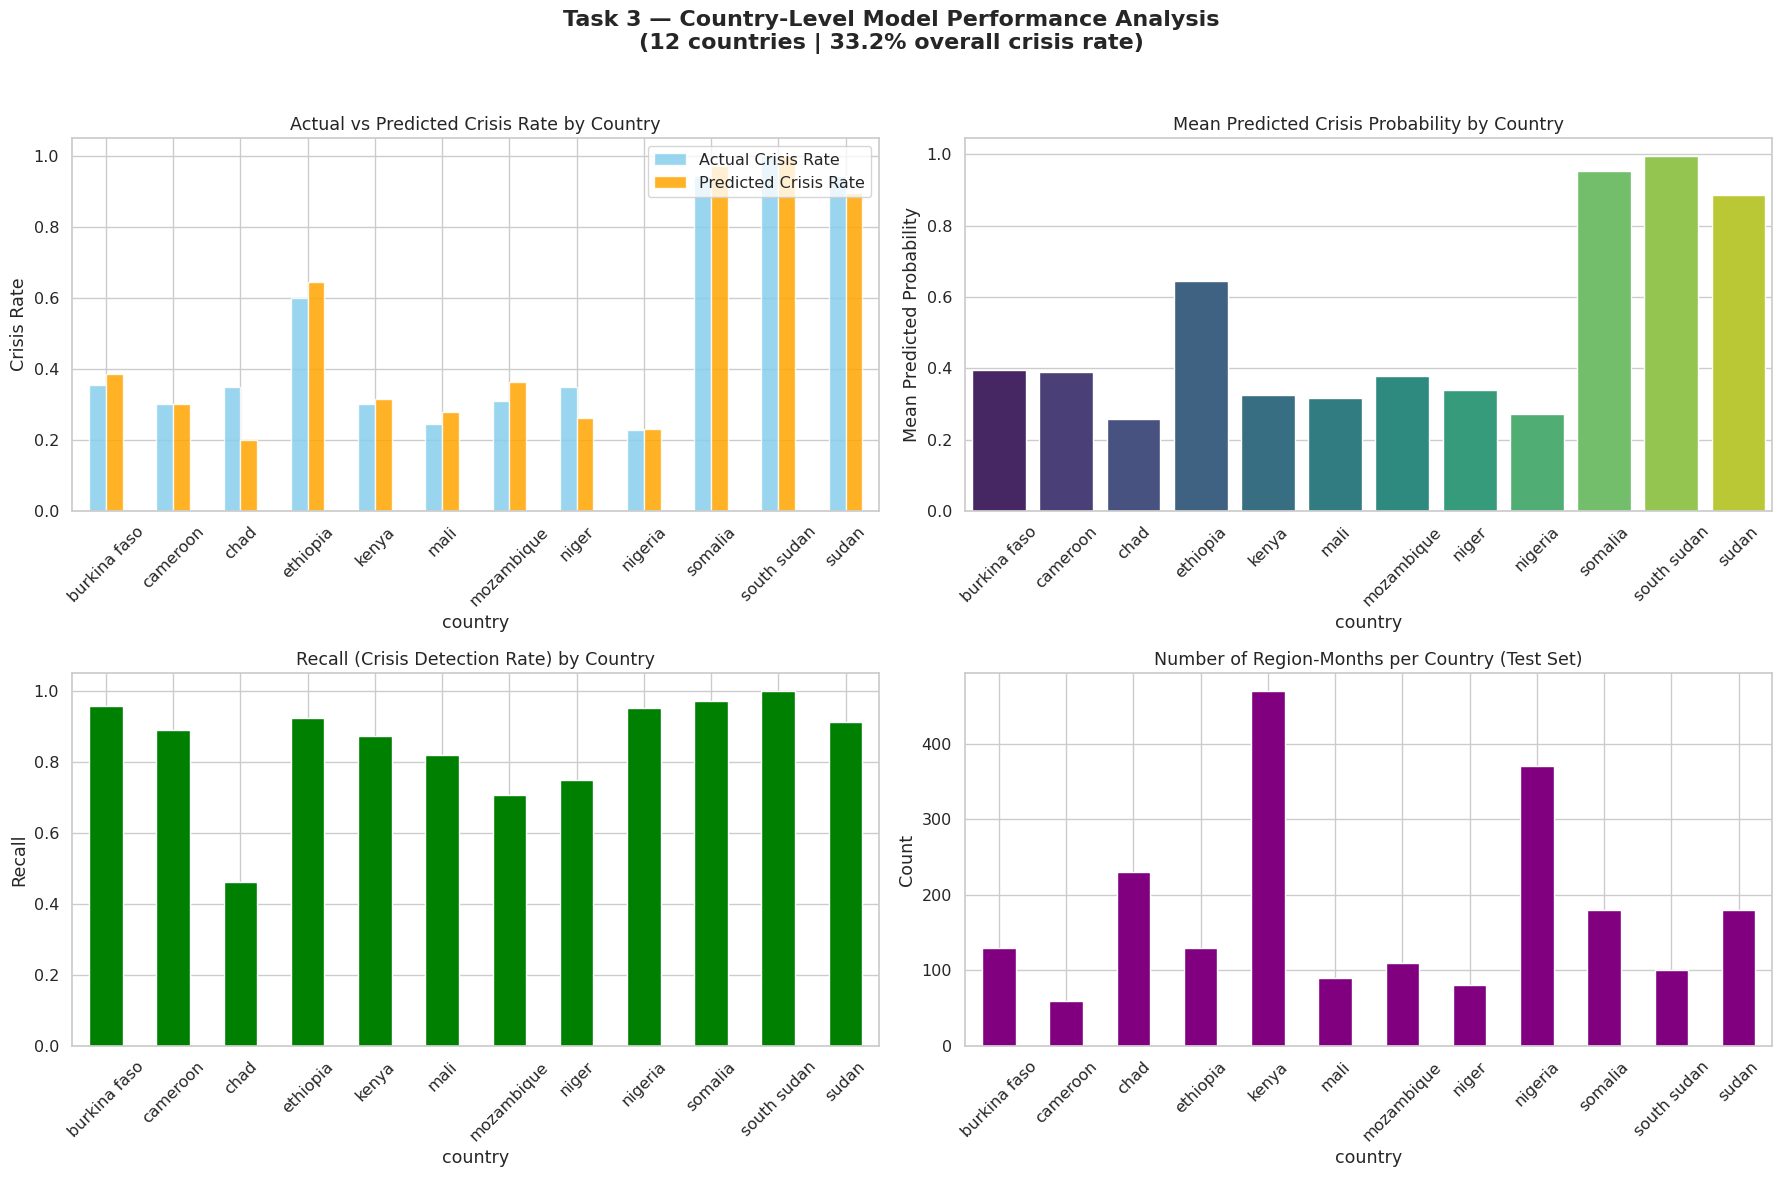

✅ Country-level visualizations saved successfully as 'country_level_analysis.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

# Load the full engineered panel which contains 'country' and 'crisis_90d'
full_panel = pd.read_csv('/content/crisis_outputs/features_engineered.csv')

# Load the trained model
xgb = joblib.load('/content/crisis_outputs/xgboost_best.pkl')

target = 'crisis_90d'

# Define columns to exclude from features for model prediction
leakage_cols = ['ipc_phase', 'population_in_crisis', 'ipc_matched',
                'country_key', 'admin1_key', 'admin1_merge'] # These are columns we want to avoid as features
# Columns that should not be used as features in the model, but might be needed for analysis
non_feature_cols_for_model = ['country', 'admin1', 'year_month', target] + leakage_cols

# Apply the test mask to the full panel to get the test data subset, including all original columns needed for analysis
# Re-create test_mask for robustness if not globally available
test_mask  = full_panel['year_month'] >= '2023-01'
test_data_for_analysis = full_panel.loc[test_mask].copy() # Keep all columns for analysis

# Now, define the actual features (X_test) and target (y_test) for model prediction
feature_cols = [col for col in test_data_for_analysis.columns if col not in non_feature_cols_for_model]

X_test = test_data_for_analysis[feature_cols]
y_test = test_data_for_analysis[target].astype(int)

# Generate predictions
test_data_for_analysis['y_pred'] = xgb.predict(X_test)
test_data_for_analysis['y_prob'] = xgb.predict_proba(X_test)[:, 1]

print(f"Predictions generated for {len(test_data_for_analysis)} test samples")

# Rename for consistency with original code for plotting parts
test_orig = test_data_for_analysis

# ====================== COUNTRY-LEVEL VISUALIZATIONS ======================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Actual vs Predicted crisis rate by country
country_stats = test_orig.groupby('country').agg({
    'crisis_90d': 'mean',
    'y_pred': 'mean',
    'y_prob': 'mean'
}).rename(columns={
    'crisis_90d': 'Actual Crisis Rate',
    'y_pred': 'Predicted Crisis Rate',
    'y_prob': 'Mean Predicted Probability'
})

country_stats[['Actual Crisis Rate', 'Predicted Crisis Rate']].plot(
    kind='bar', ax=axes[0,0], color=['skyblue', 'orange'], alpha=0.85)
axes[0,0].set_title('Actual vs Predicted Crisis Rate by Country')
axes[0,0].set_ylabel('Crisis Rate')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(loc='upper right')

# 2. Mean predicted probability by country
sns.barplot(data=country_stats.reset_index(), x='country', y='Mean Predicted Probability',
            ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Mean Predicted Crisis Probability by Country')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Recall (Crisis Detection Rate) by country
# Ensure the denominator is not zero to avoid division by zero errors, especially for countries with no actual crisis
recall_by_country = test_orig.groupby('country').apply(
    lambda x: ((x['y_pred'] == 1) & (x['crisis_90d'] == 1)).sum() / x['crisis_90d'].sum() if x['crisis_90d'].sum() > 0 else 0
)
recall_by_country.plot(kind='bar', ax=axes[1,0], color='green')
axes[1,0].set_title('Recall (Crisis Detection Rate) by Country')
axes[1,0].set_ylabel('Recall')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Number of region-months per country
test_orig.groupby('country').size().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Number of Region-Months per Country (Test Set)')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Task 3 — Country-Level Model Performance Analysis\n(12 countries | 33.2% overall crisis rate)',
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('/content/crisis_outputs/country_level_analysis.png', dpi=180, bbox_inches='tight')
plt.show()

print("✅ Country-level visualizations saved successfully as 'country_level_analysis.png'")

Predictions generated for 2130 test samples
Aggregated 213 admin1 regions with mean crisis probability
✅ Interactive country-level map saved as 'country_crisis_map.html'
Open the HTML file in your browser to explore.


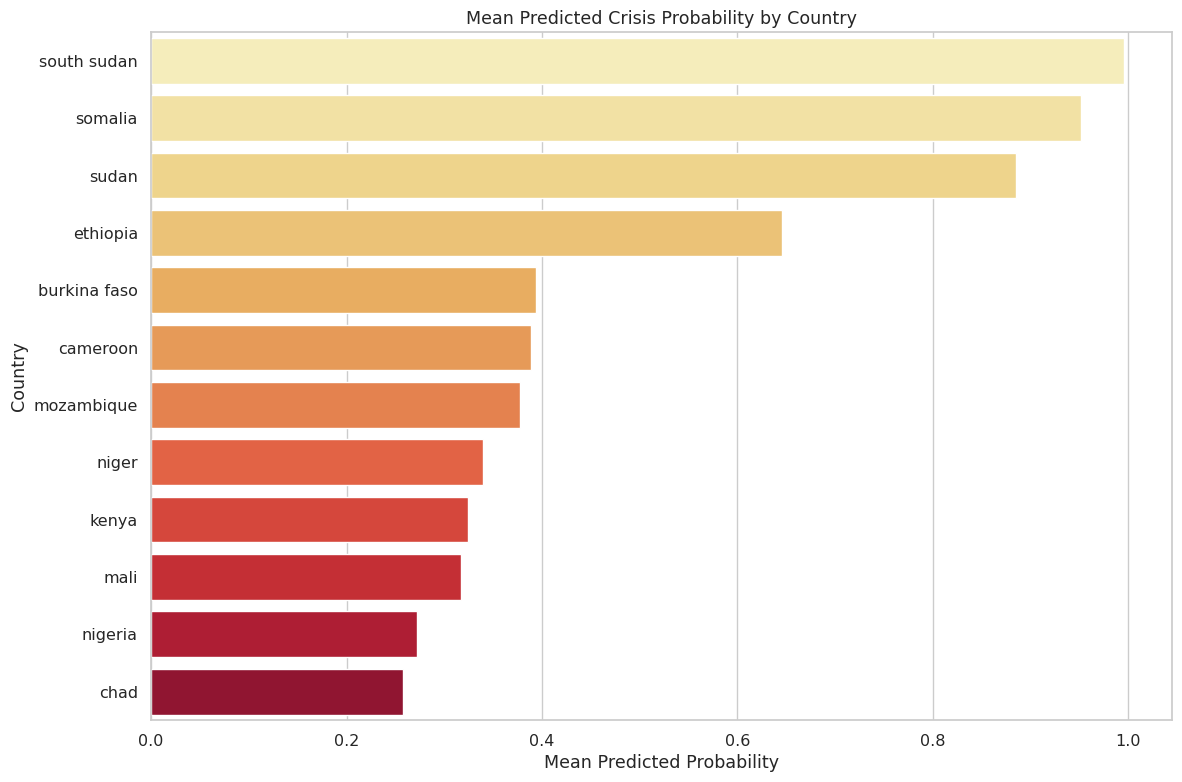

✅ Static bar chart saved as 'country_crisis_bar.png'


In [ ]:
import geopandas as gpd
import folium
from folium import Choropleth
import matplotlib.pyplot as plt
import pandas as pd
import joblib

# Load the full engineered panel which contains 'country' and 'crisis_90d'
full_panel = pd.read_csv('/content/crisis_outputs/features_engineered.csv')

# Load the trained model
xgb = joblib.load('/content/crisis_outputs/xgboost_best.pkl')

target = 'crisis_90d'

# Define columns to exclude from features for model prediction
leakage_cols = ['ipc_phase', 'population_in_crisis', 'ipc_matched',
                'country_key', 'admin1_key', 'admin1_merge'] # These are columns we want to avoid as features
# Columns that should not be used as features in the model, but might be needed for analysis
non_feature_cols_for_model = ['country', 'admin1', 'year_month', target] + leakage_cols

# Apply the test mask to the full panel to get the test data subset, including all original columns needed for analysis
# Re-create test_mask for robustness if not globally available
test_mask  = full_panel['year_month'] >= '2023-01'
test_data_for_analysis = full_panel.loc[test_mask].copy() # Keep all columns for analysis

# Now, define the actual features (X_test) and target (y_test) for model prediction
feature_cols = [col for col in test_data_for_analysis.columns if col not in non_feature_cols_for_model]

X_test = test_data_for_analysis[feature_cols]
y_test = test_data_for_analysis[target].astype(int)

# Generate predictions
test_data_for_analysis['y_pred'] = xgb.predict(X_test)
test_data_for_analysis['y_prob'] = xgb.predict_proba(X_test)[:, 1]

print(f"Predictions generated for {len(test_data_for_analysis)} test samples")

# Rename for consistency with original code for plotting parts
test_orig = test_data_for_analysis

# Aggregate mean predicted probability per country + admin1
agg_df = test_orig.groupby(['country', 'admin1'])['y_prob'].mean().reset_index()
agg_df = agg_df.rename(columns={'y_prob': 'mean_crisis_prob'})

print(f"Aggregated {len(agg_df)} admin1 regions with mean crisis probability")

# ====================== INTERACTIVE FOLIUM MAP ======================
m = folium.Map(location=[5, 20], zoom_start=4, tiles="CartoDB positron")

# For simplicity, we use country-level first (admin1 would require full shapefile matching)
country_agg = agg_df.groupby('country')['mean_crisis_prob'].mean().reset_index()

# Simple country-level choropleth (using built-in world countries for quick view)
folium.Choropleth(
    geo_data="https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json",
    name="choropleth",
    data=country_agg,
    columns=["country", "mean_crisis_prob"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Mean Predicted Crisis Probability",
).add_to(m)

folium.LayerControl().add_to(m)
m.save('/content/crisis_outputs/country_crisis_map.html')

print("✅ Interactive country-level map saved as 'country_crisis_map.html'")
print("Open the HTML file in your browser to explore.")

# ====================== STATIC MATPLOTLIB CHOROPLETH (Country Level) ======================
# For admin-1 level we would need full shapefile, so showing country level for now
plt.figure(figsize=(12, 8))
sns.barplot(data=country_agg.sort_values('mean_crisis_prob', ascending=False),
            x='mean_crisis_prob', y='country', palette='YlOrRd')
plt.title('Mean Predicted Crisis Probability by Country')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('/content/crisis_outputs/country_crisis_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Static bar chart saved as 'country_crisis_bar.png'")

In [ ]:
import pandas as pd

# Let's see what columns we actually have
print("=== Checking Available Files ===")

try:
    xtest = pd.read_csv('/content/crisis_outputs/X_test.csv')
    print("X_test.csv columns:", list(xtest.columns))
except:
    print("X_test.csv not found")

try:
    engineered = pd.read_csv('/content/crisis_outputs/features_engineered.csv')
    print("\nfeatures_engineered.csv columns include 'country'?", 'country' in engineered.columns)
    print("features_engineered shape:", engineered.shape)
    print("Sample columns:", list(engineered.columns)[:15])  # first 15 columns
except Exception as e:
    print("Error loading engineered file:", str(e))

=== Checking Available Files ===
X_test.csv columns: ['crisis_90d', 'ipc_lag1', 'ipc_lag2', 'fatalities_30d', 'events_30d', 'battle_events', 'civilian_violence', 'conflict_trend', 'rainfall_mm', 'rainfall_anomaly', 'is_drought', 'is_flood', 'is_lean_season', 'is_harvest_season', 'year', 'fatalities_lag1', 'events_lag1', 'fatalities_lag2', 'events_lag2', 'fatalities_lag3', 'events_lag3', 'fatalities_roll2', 'fatalities_roll3', 'events_roll3', 'fatalities_delta', 'fatalities_accel', 'rainfall_lag1', 'rainfall_lag2', 'rainfall_roll3', 'ipc_trend', 'high_conflict', 'high_conflict_drought', 'conflict_intensity_norm', 'drought_severity_norm', 'compound_risk_score', 'battle_share', 'sustained_conflict', 'month']

features_engineered.csv columns include 'country'? True
features_engineered shape: (14058, 43)
Sample columns: ['country', 'admin1', 'year_month', 'ipc_phase', 'population_in_crisis', 'crisis_90d', 'ipc_lag1', 'ipc_lag2', 'fatalities_30d', 'events_30d', 'battle_events', 'civilian_vio

In [ ]:
import pandas as pd
import folium
import joblib
from branca.colormap import linear

# 1. Load the full engineered file (this one has 'country')
full_test = pd.read_csv('/content/crisis_outputs/features_engineered.csv')

# Filter to the test period only (same as your modeling)
test_mask = full_test['year_month'] >= '2023-01'
test_orig = full_test[test_mask].copy()

print(f"Test rows loaded: {len(test_orig)}")

# 2. Load model
xgb = joblib.load('/content/crisis_outputs/xgboost_best.pkl')

# 3. Define features safely (exclude leakage + metadata)
target = 'crisis_90d'
leakage_cols = ['ipc_phase', 'population_in_crisis', 'ipc_matched',
                'country_key', 'admin1_key', 'admin1_merge', 'country', 'admin1', 'year_month']

feature_cols = [col for col in test_orig.columns if col not in leakage_cols + [target]]

print(f"Using {len(feature_cols)} features for prediction")

# 4. Predict
X_test = test_orig[feature_cols]
test_orig['y_prob'] = xgb.predict_proba(X_test)[:, 1]

# 5. Aggregate by country
country_agg = test_orig.groupby('country')['y_prob'].mean().reset_index()
country_agg = country_agg.rename(columns={'y_prob': 'mean_crisis_prob'})
country_agg['country'] = country_agg['country'].str.title().str.strip()

print("\nTop 8 highest risk countries:")
print(country_agg.sort_values('mean_crisis_prob', ascending=False).head(8))

# ====================== FINAL IMPROVED MAP ======================
m = folium.Map(location=[5, 20], zoom_start=4, tiles="CartoDB dark_matter")

colormap = linear.YlOrRd_09.scale(0.25, 0.98)

folium.Choropleth(
    geo_data="https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json",
    data=country_agg,
    columns=['country', 'mean_crisis_prob'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.88,
    line_opacity=0.7,
    line_weight=1.2,
    legend_name='Mean Predicted Crisis Probability (2023+)',
    highlight=True
).add_to(m)

# Hover tooltips
folium.GeoJson(
    "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json",
    style_function=lambda feature: {'fillColor': 'transparent', 'color': '#ffffff', 'weight': 0.8},
    tooltip=folium.GeoJsonTooltip(fields=['name'], aliases=['Country: '], localize=True)
).add_to(m)

folium.LayerControl().add_to(m)

m.save('/content/crisis_outputs/africa_crisis_map_fixed.html')
print("\n✅ Map saved successfully as africa_crisis_map_fixed.html")
display(m)

Test rows loaded: 2130
Using 37 features for prediction

Top 8 highest risk countries:
         country  mean_crisis_prob
10   South Sudan          0.995113
9        Somalia          0.951938
11         Sudan          0.885500
3       Ethiopia          0.645803
0   Burkina Faso          0.394331
1       Cameroon          0.389024
6     Mozambique          0.377244
7          Niger          0.339724

✅ Map saved successfully as africa_crisis_map_fixed.html
